# Недвижимость в Калифорнии

## Загрузка датасета

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Загружаем как DataFrame чтобы получить MedHouseVal
housing = fetch_california_housing(as_frame=True)

# Весь датасет
df = housing.frame
print("Все столбцы:", df.columns.tolist())

# Разделяем на признаки (X) и целевую переменную (y)
X = df.drop('MedHouseVal', axis=1)  # или X = housing.data
y = df['MedHouseVal']               # или y = housing.target

print(f"\nПризнаки: {X.shape}")
print(f"Целевая переменная (MedHouseVal): {y.shape}")

Все столбцы: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Признаки: (20640, 8)
Целевая переменная (MedHouseVal): (20640,)


## Информация о признаках

In [2]:
print(fetch_california_housing().DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

## Разделение выборки на обучающую и тестовую

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (16512, 8), X_test: (4128, 8)
y_train: (16512,), y_test: (4128,)


## Проверка на пропуски и удаление

In [4]:
# Проверка пропусков
print("Пропуски в обучающей выборке:")
print(X_train.isnull().sum())
print(f"\nВсего пропусков: {X_train.isnull().sum().sum()}")

# Удаление пропусков (если они есть)
if X_train.isnull().sum().sum() > 0:
    X_train = X_train.dropna()
    y_train = y_train[X_train.index]  # синхронное удаление в целевой переменной

print(f"\nПосле обработки: {X_train.shape}, {y_train.shape}")

Пропуски в обучающей выборке:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Всего пропусков: 0

После обработки: (16512, 8), (16512,)


## Линейная регрессия

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Модель
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Предсказание и сравнение с истинным значением

In [6]:
# Предсказание на тестовом множестве
y_pred = model.predict(X_test)

# Сравнение с истинными значениями через score
test_score = model.score(X_test, y_test)

print(f"Точность модели на тесте (R²): {test_score:.4f}")
print(f"Пример: Предсказано {y_pred[0]:.3f}, Истина {y_test.iloc[0]:.3f}")

Точность модели на тесте (R²): 0.5758
Пример: Предсказано 0.719, Истина 0.477


## Дерево решений без ограничений глубины (переобученное)

Точность дерева на тесте (R²): 0.6221


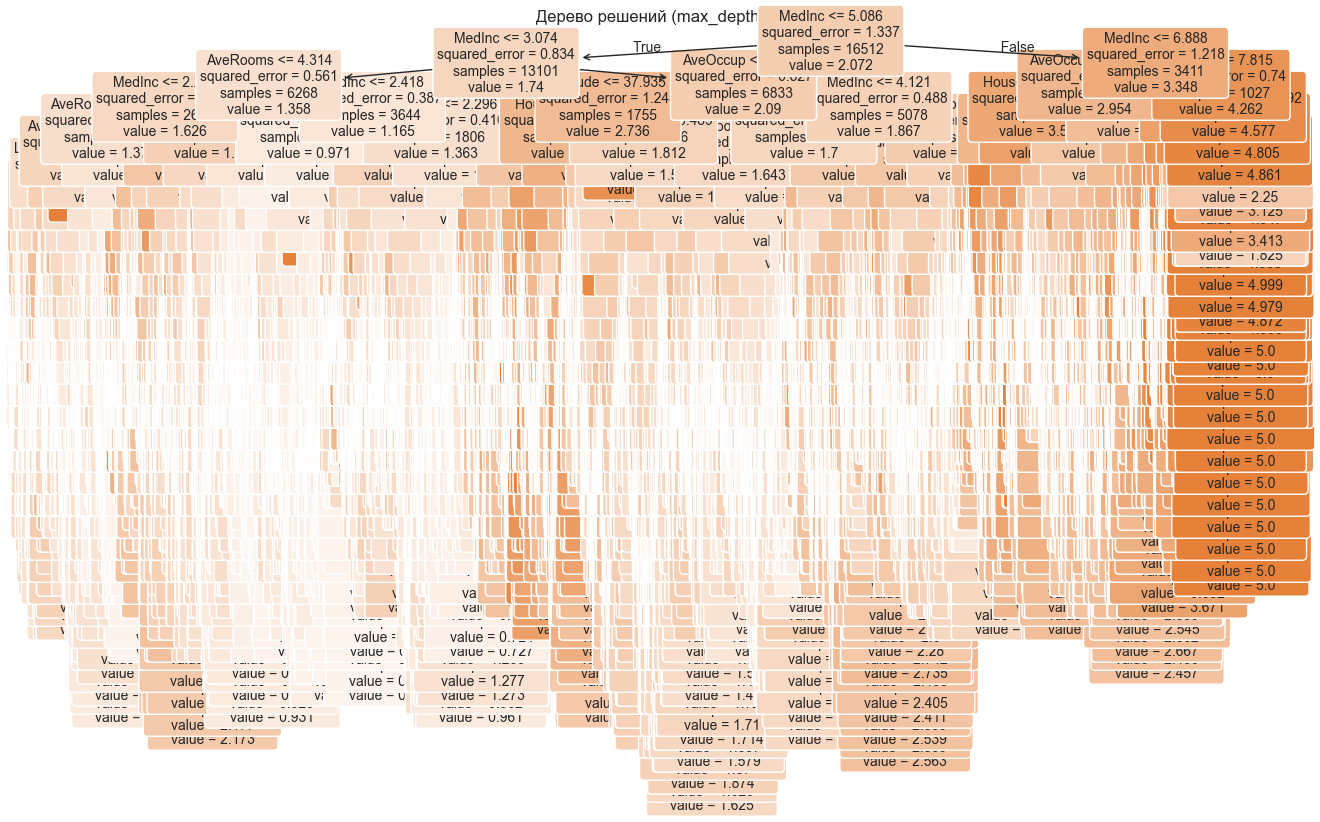

In [8]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# a. Обучение дерева решений
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Повтор п.5
y_pred_tree = tree_model.predict(X_test)
test_score_tree = tree_model.score(X_test, y_test)

print(f"Точность дерева на тесте (R²): {test_score_tree:.4f}")

# b. Визуализация части дерева
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plot_tree(tree_model,
          feature_names=X_train.columns.tolist(),
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Дерево решений без ограничения глубины")
plt.show()

## Дерево решений с ограничением глубины

Точность дерева на тесте (R²): 0.5997


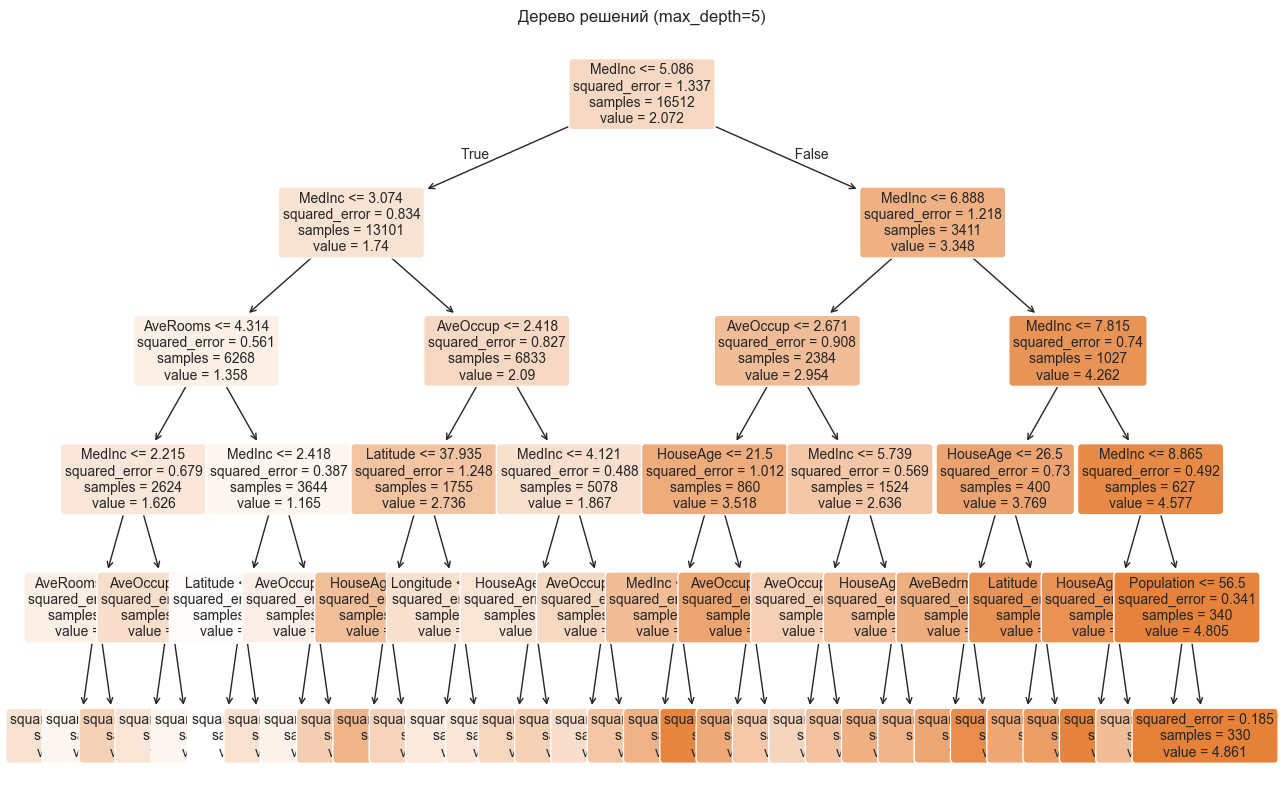

In [9]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# a. Обучение дерева решений
tree_model = DecisionTreeRegressor(random_state=42, max_depth=5)
tree_model.fit(X_train, y_train)

# Повтор п.5
y_pred_tree = tree_model.predict(X_test)
test_score_tree = tree_model.score(X_test, y_test)

print(f"Точность дерева на тесте (R²): {test_score_tree:.4f}")

# b. Визуализация части дерева
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plot_tree(tree_model,
          feature_names=X_train.columns.tolist(),
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Дерево решений (max_depth=5)")
plt.show()

Точность дерева на тесте (R²): 0.5098


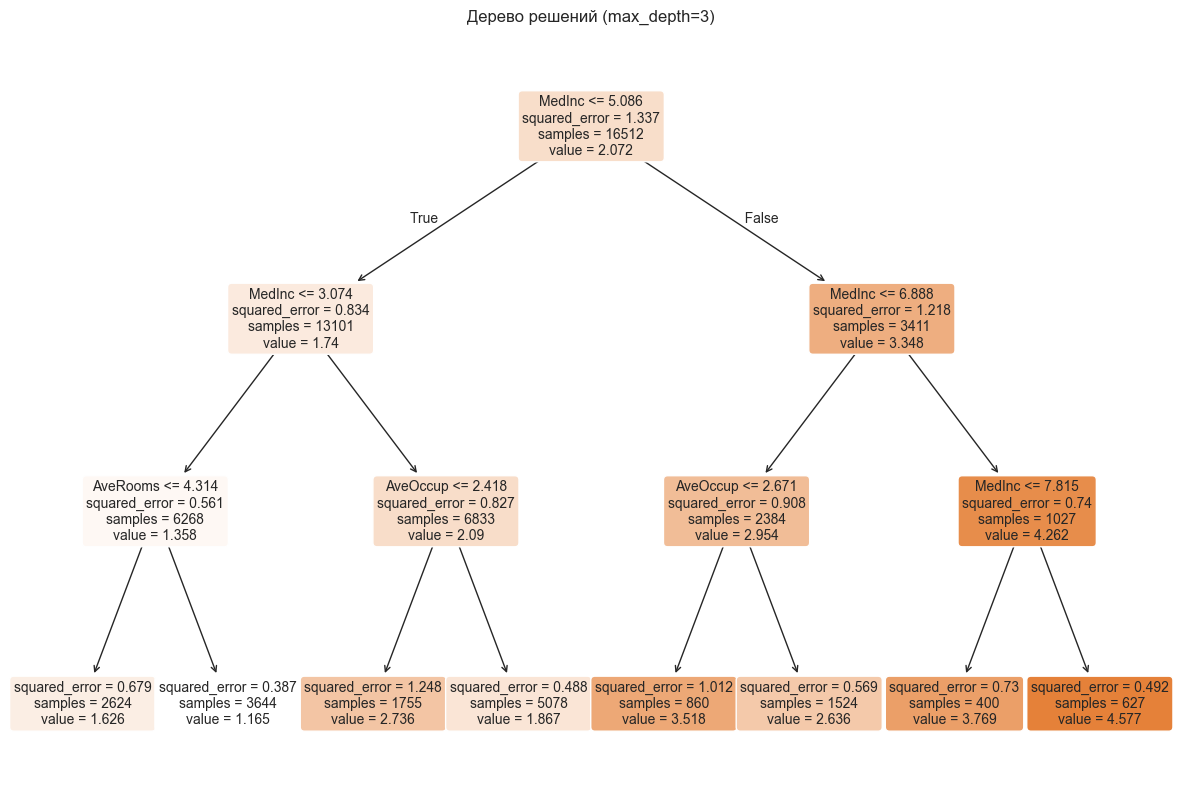

In [10]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# a. Обучение дерева решений
tree_model = DecisionTreeRegressor(random_state=42, max_depth=3)
tree_model.fit(X_train, y_train)

# Повтор п.5
y_pred_tree = tree_model.predict(X_test)
test_score_tree = tree_model.score(X_test, y_test)

print(f"Точность дерева на тесте (R²): {test_score_tree:.4f}")

# b. Визуализация части дерева
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plot_tree(tree_model,
          feature_names=X_train.columns.tolist(),
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Дерево решений (max_depth=3)")
plt.show()

Точность дерева на тесте (R²): 0.6829


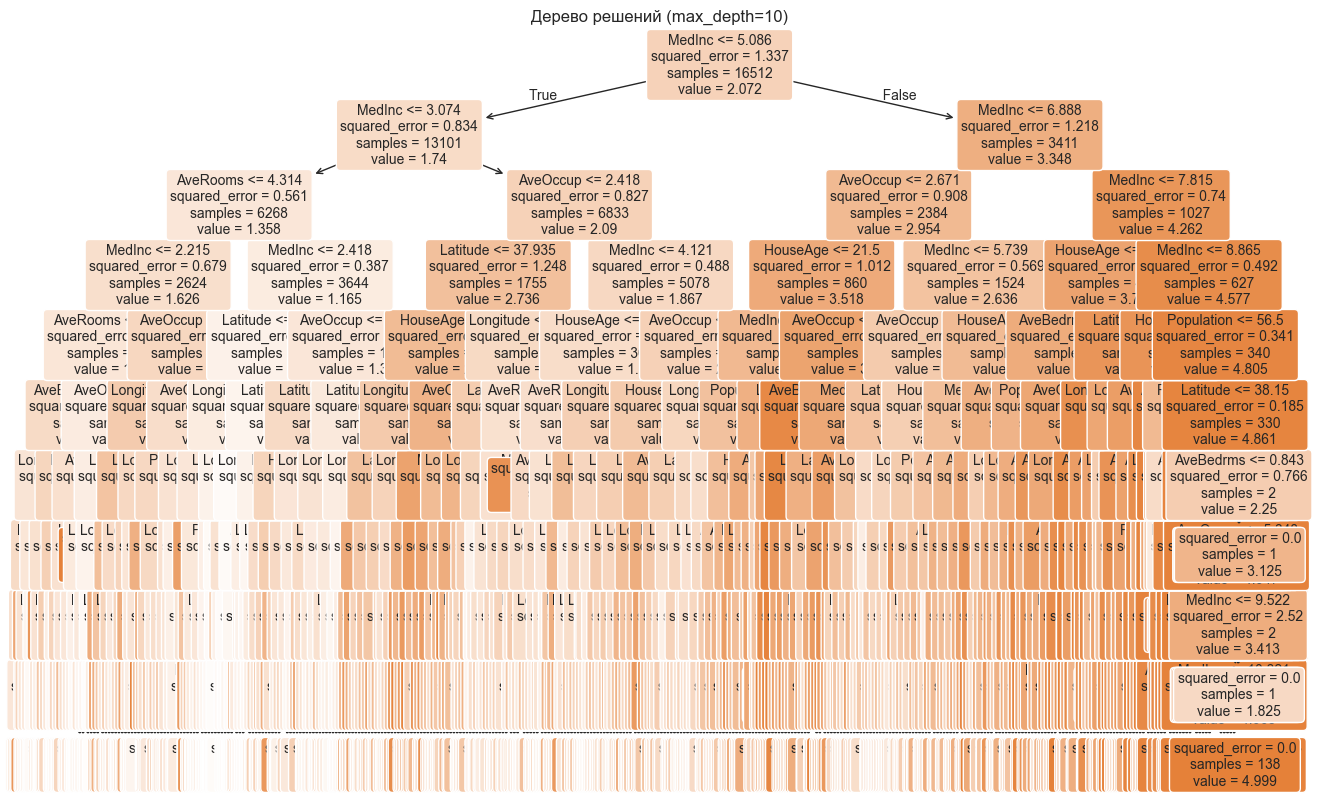

In [14]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# a. Обучение дерева решений
tree_model = DecisionTreeRegressor(random_state=42, max_depth=10)
tree_model.fit(X_train, y_train)

# Повтор п.5
y_pred_tree = tree_model.predict(X_test)
test_score_tree = tree_model.score(X_test, y_test)

print(f"Точность дерева на тесте (R²): {test_score_tree:.4f}")

# b. Визуализация части дерева
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plot_tree(tree_model,
          feature_names=X_train.columns.tolist(),
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Дерево решений (max_depth=10)")
plt.show()

## Выводы по работе

### a. Сравнение точности моделей

| Модель | R² на тесте | Объясняемая дисперсия | RMSE (примерно) |
|--------|------------|----------------------|-----------------|
| **Линейная регрессия** | 0.5758 | 57.6% | ~0.7456 |
| **Дерево решений (depth=10)** | **0.6829** | **68.3%** | **~0.6321** |

**Результат:** Дерево решений **значительно лучше** (на +10.7 процентных пункта), ошибка уменьшилась примерно на 15%.

### b. Применение моделей

#### Линейная регрессия

**Плюсы:**
- Быстрая обучение и предсказание
- Интерпретируемость коэффициентов
- Хорошо экстраполирует за пределы данных
- Стабильность на маленьких выборках

**Минусы:**
- Предположение о линейности (часто не выполняется)
- Чувствительность к выбросам
- Не улавливает сложные нелинейные зависимости

**Где использовать:**
- Быстрые прототипы
- Когда важна интерпретируемость (например, для бизнес-отчетов)
- Данные с линейной зависимостью
- Маленькие datasets

#### Дерево решений

**Плюсы:**
- Улавливает нелинейные зависимости
- Нечувствительность к выбросам
- Не требует масштабирования признаков
- Отличная интерпретируемость (визуализация дерева)

**Минусы:**
- Склонность к переобучению (нужны ограничения)
- Нестабильность (малые изменения данных → другое дерево)
- Плохая экстраполяция за пределы данных
- Дискретные границы разделения

**Где использовать:**
- Данные со сложными нелинейными зависимостями
- Когда важны правила принятия решений
- Разведочный анализ (понимание важности признаков)
- Табличные данные с mix типов признаков
